In [61]:
import pandas as pd
from sagemaker.core.helper.session_helper import Session
from dotenv import load_dotenv
import boto3
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import RFE
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
import optuna
import xgboost as xgb
from sklearn.metrics import r2_score, root_mean_squared_error
pd.set_option('display.max_columns', None)


In [ ]:
load_dotenv()

sm_boto3 = boto3.client('sagemaker')
session = Session()
region = session.boto_session.region_name

s3_csv_uri = 's3://crab-data-s3-bucket-050730647658-us-east-1-an/CrabAgePrediction.csv'

In [2]:
df = pd.read_csv(s3_csv_uri)

c:\Users\gerar\anaconda3\envs\DataScience\Lib\site-packages\fsspec\registry.py:305: UserWarning: Your installed version of s3fs is very old and known to cause
severe performance issues, see also https://github.com/dask/dask/issues/10276

To fix, you should specify a lower version bound on s3fs, or
update the current installation.

  warnings.warn(s3_msg)


                    INFO     Found credentials in environment variables.                        ]8;id=7734346;file://c:\Users\gerar\anaconda3\envs\DataScience\Lib\site-packages\botocore\credentials.py\credentials.py]8;;\:]8;id=7734347;file://c:\Users\gerar\anaconda3\envs\DataScience\Lib\site-packages\botocore\credentials.py#1252\1252]8;;\

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3893 entries, 0 to 3892
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             3893 non-null   object 
 1   Length          3893 non-null   float64
 2   Diameter        3893 non-null   float64
 3   Height          3893 non-null   float64
 4   Weight          3893 non-null   float64
 5   Shucked Weight  3893 non-null   float64
 6   Viscera Weight  3893 non-null   float64
 7   Shell Weight    3893 non-null   float64
 8   Age             3893 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 273.9+ KB
None


In [5]:
print(df.describe())

            Length     Diameter  ...  Shell Weight          Age
count  3893.000000  3893.000000  ...   3893.000000  3893.000000
mean      1.311306     1.020893  ...      6.795844     9.954791
std       0.300431     0.248233  ...      3.943392     3.220967
min       0.187500     0.137500  ...      0.042524     1.000000
25%       1.125000     0.875000  ...      3.713785     8.000000
50%       1.362500     1.062500  ...      6.662133    10.000000
75%       1.537500     1.200000  ...      9.355335    11.000000
max       2.037500     1.625000  ...     28.491248    29.000000

[8 rows x 8 columns]


In [6]:
print(df.nunique())

Sex                  3
Length             134
Diameter           111
Height              51
Weight            2343
Shucked Weight    1482
Viscera Weight     867
Shell Weight       907
Age                 28
dtype: int64


In [7]:
print(100.0 * df.isna().sum() / len(df))
df.duplicated().sum()

Sex               0.0
Length            0.0
Diameter          0.0
Height            0.0
Weight            0.0
Shucked Weight    0.0
Viscera Weight    0.0
Shell Weight      0.0
Age               0.0
dtype: float64


np.int64(0)

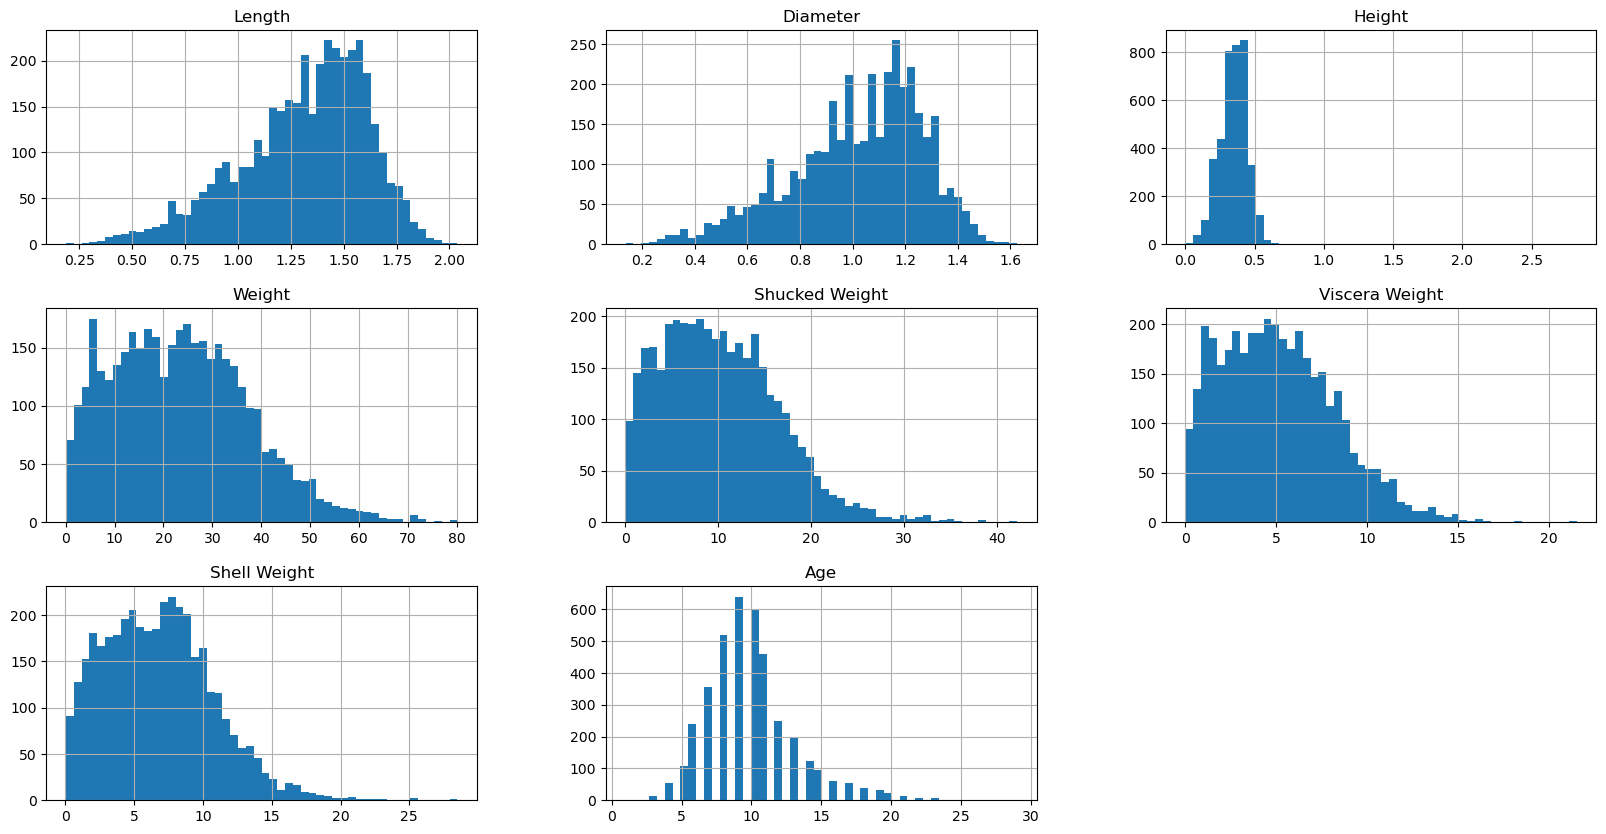

In [ ]:


df.hist(bins = 50, figsize = (20,10))
plt.show()

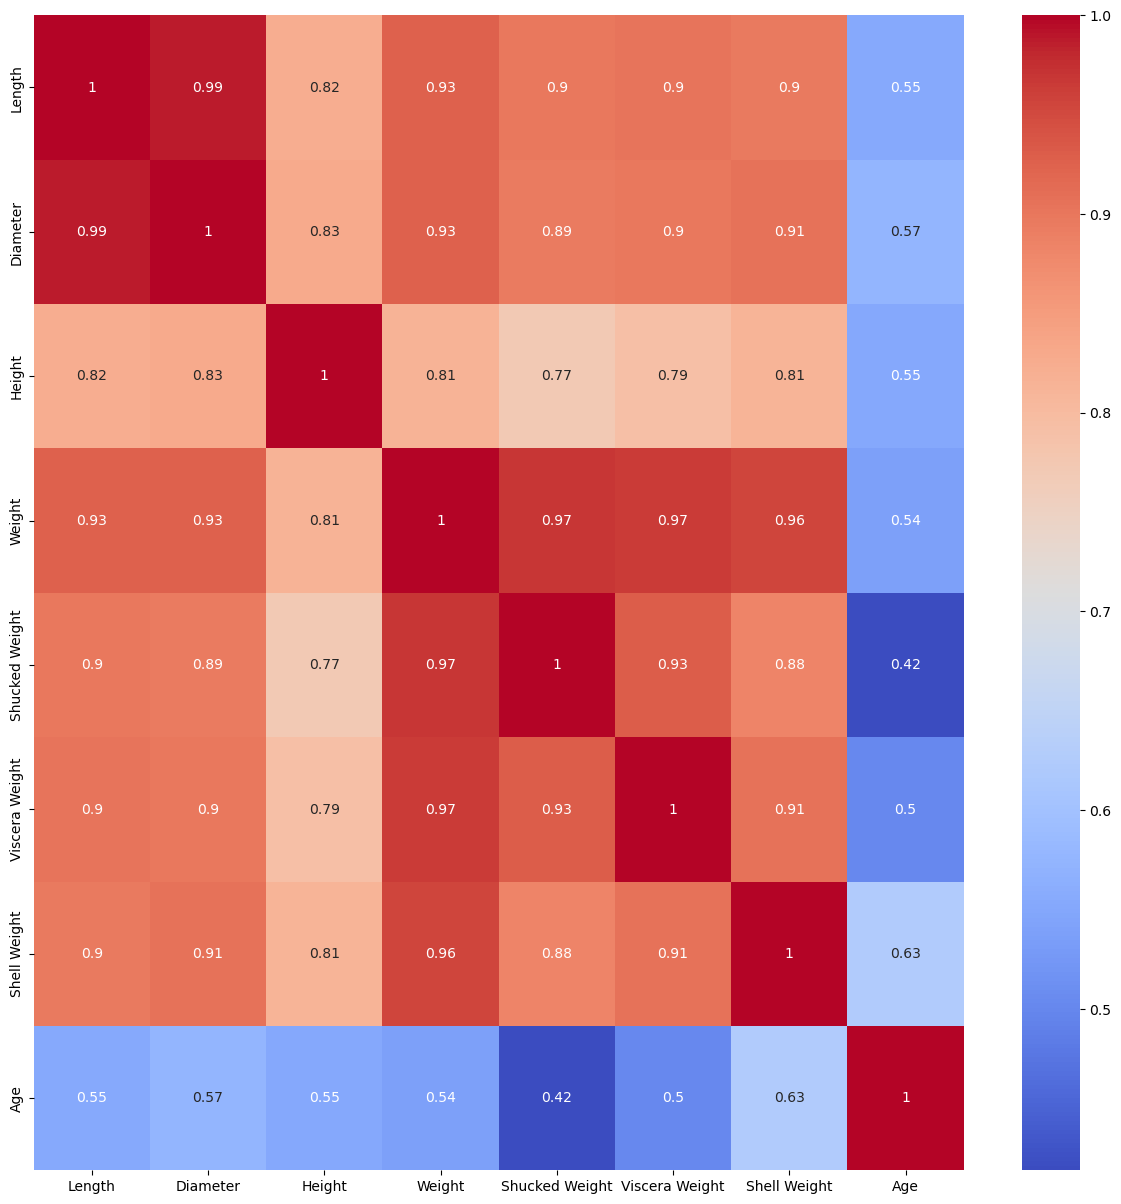

In [9]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(15,15))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

In [57]:
y = df['Age']
X = df.drop(columns='Age')
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder(sparse_output=False)
sex_encoded = enc.fit_transform(X[['Sex']])
df_encoded = pd.DataFrame(sex_encoded, columns=enc.get_feature_names_out(['Sex']))
X = X.drop(columns='Sex')
X = pd.concat([X, df_encoded], axis=1)

In [58]:
X_selected = X.copy()


In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42)

In [66]:
def objective(trial):
    param = {
        "verbosity": 0,
        "objective": "reg:squarederror",
        "eval_metric": "rmse",
        "n_estimators": trial.suggest_int("n_estimators", 50, 2000),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 1e-8, 1.0, log=True),
    }

    pipeline = Pipeline([
        (
            "selector",
            RFE(
                estimator=xgb.XGBRegressor(
                    verbosity=0,
                    objective="reg:squarederror",
                    eval_metric="rmse",
                ),
                n_features_to_select=7,
                step=1,
            ),
        ),
        ("regressor", xgb.XGBRegressor(**param)),
    ])

    score = cross_val_score(
        pipeline,
        X_train,
        y_train,
        n_jobs=-1,
        cv=5,
        scoring='neg_root_mean_squared_error',
        error_score='raise',
    ).mean()
    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

selector = RFE(
    estimator=xgb.XGBRegressor(
        verbosity=0,
        objective="reg:squarederror",
        eval_metric="rmse",
    ),
    n_features_to_select=7,
    step=1,
)

selector.fit(X_train, y_train)
selected_columns = X_train.columns[selector.get_support()]

X_train_selected = X_train[selected_columns]
X_test_selected = X_test[selected_columns]


[I 2026-05-25 11:01:11,621] A new study created in memory with name: no-name-269631d3-8795-4e79-ae28-bc99c47b35f5
[I 2026-05-25 11:01:15,646] Trial 0 finished with value: -2.7706536293029784 and parameters: {'n_estimators': 312, 'learning_rate': 0.0011850231857612596, 'max_depth': 11, 'subsample': 0.6568593567584778, 'colsample_bytree': 0.9045159595814305, 'gamma': 0.01741337607751227}. Best is trial 0 with value: -2.7706536293029784.
[I 2026-05-25 11:01:18,221] Trial 1 finished with value: -2.1856786966323853 and parameters: {'n_estimators': 872, 'learning_rate': 0.008685276067345161, 'max_depth': 6, 'subsample': 0.6335269598888709, 'colsample_bytree': 0.9931837964190289, 'gamma': 0.02972024380025238}. Best is trial 1 with value: -2.1856786966323853.
[I 2026-05-25 11:01:24,050] Trial 2 finished with value: -2.3473979473114013 and parameters: {'n_estimators': 1505, 'learning_rate': 0.05246504480656727, 'max_depth': 10, 'subsample': 0.5711068700916229, 'colsample_bytree': 0.788029199784

In [68]:
model = xgb.XGBRegressor(**study.best_params)
model.fit(X_train_selected, y_train)
y_pred = model.predict(X_test_selected)
test_rmse = root_mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)  
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test R²: {test_r2:.4f}")


Test RMSE: 2.0812
Test R²: 0.5493


In [70]:
import joblib
joblib.dump(model, 'model/model.pkl')


['model/model.pkl']

In [72]:
selected_mask = selector.get_support()
selected_features = X_train.columns[selected_mask].tolist()
print(selected_features)

['Weight', 'Shucked Weight', 'Viscera Weight', 'Shell Weight', 'Sex_F', 'Sex_I', 'Sex_M']
